In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder, StandardScaler

## **EDA**

In [ ]:
df=pd.read_csv("/content/mumbai_housing_realistic.csv")

In [ ]:
df.head()

,area_sqft,rooms,age_years,locality_type,location_score,price_in_inr
0,1337.0,4,22,mid_range,73.3,40686574
1,746.0,2,26,mid_range,78.1,22919933
2,701.0,3,39,premium,92.8,25495655
3,1161.0,3,30,mid_range,79.4,29846273
4,1346.0,5,8,suburban,71.3,33689780


In [ ]:
df.isnull()
df.isnull().sum()

,0
area_sqft,0
rooms,0
age_years,0
locality_type,0
location_score,0
price_in_inr,0


In [ ]:
df.shape

(1500, 6)

In [ ]:
df.columns

Index(['area_sqft', 'rooms', 'age_years', 'locality_type', 'location_score',
       'price_in_inr'],
      dtype='object')

In [ ]:
df.index

RangeIndex(start=0, stop=1500, step=1)

In [ ]:
df.dtypes

,0
area_sqft,float64
rooms,int64
age_years,int64
locality_type,object
location_score,float64
price_in_inr,int64


In [ ]:
df.size

9000

## **ML**

In [ ]:
df.head()

,area_sqft,rooms,age_years,locality_type,location_score,price_in_inr
0,1337.0,4,22,mid_range,73.3,40686574
1,746.0,2,26,mid_range,78.1,22919933
2,701.0,3,39,premium,92.8,25495655
3,1161.0,3,30,mid_range,79.4,29846273
4,1346.0,5,8,suburban,71.3,33689780


In [ ]:
x=df[["area_sqft", "rooms", "age_years", "location_score"]]
y= df["price_in_inr"]

In [ ]:
model=Ridge()

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.30)

In [ ]:
std = StandardScaler()
x_train_std = std.fit_transform(x_train)
x_test_std = std.transform(x_test)

In [ ]:
kf=KFold(n_splits=5, shuffle=True, random_state=42)
y_train_pred=cross_val_predict(model,x_train_std,y_train,cv=kf)

In [ ]:
model.fit(x_train_std,y_train)

Ridge()

In [ ]:
mset=mean_squared_error(y_train, y_train_pred)
maet=mean_absolute_error(y_train, y_train_pred)
print(mset)
print(maet)

57011520355482.44
5584114.248478481


In [ ]:
y_test_predict=model.predict(x_test_std)

In [ ]:
mset1=mean_squared_error(y_test, y_test_predict)
maet1=mean_absolute_error(y_test, y_test_predict)
print(mset1)
print(maet1)

61323968676774.97
5513135.8284826595


In [ ]:
y_pred=model.predict(std.transform([[800,3,10,80]]))
print(y_pred)

[28958726.28876427]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


<Axes: xlabel='price_in_inr'>

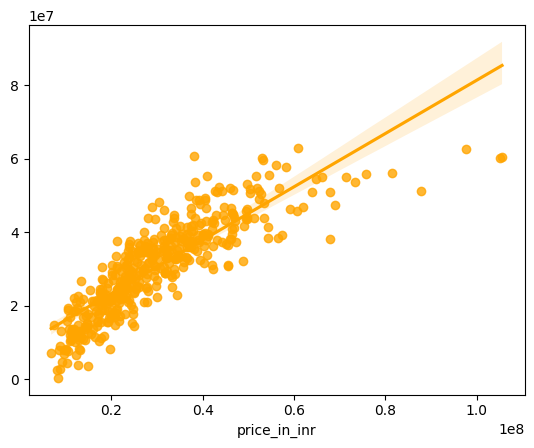

In [ ]:
sns.regplot(x=y_test,y=y_test_predict,data=df,color="orange")